# sisireg building blocks: ssr3d and ssrMLP (sisireg)

This notebook demonstrates the **regression building blocks** of the
R package **sisireg** 1.2.1 as ported to pure NumPy:

* **`ssr3d`** — the spatial minimal-surface Sign-Simplicity-Regression
  of Metzner (R `ssr3d.R` + the `ssr3d.c` Gauss-Seidel kernel):
  scattered planar data `z = f(x, y)` is smoothed by replacing every
  observation with the exponential/minimal-surface weighted mean of
  its k-quadrant and `4k+1` nearest-neighbourhoods, reverting updates
  that would violate the partial-sum adequacy criterion;
* **`ssrmlp_train` / `ssrmlp_predict`** — a two-hidden-layer sigmoid
  perceptron trained with the partial sum criterion (`opt="ps"`),
  i.e. the machine-learning building block that shares the sign
  adequacy machinery with the `unfold_ssr` unfolding method.

Both ports were verified against the original R output (R 4.5.0 +
sisireg 1.2.1) to machine precision; the fixtures used for that
verification are re-checked below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold.core import (
    ssr3d,
    ssr3d_predict,
    ssrmlp_train,
    ssrmlp_predict,
)


## 1. Spatial minimal-surface regression (`ssr3d`, R `ssr3d.R` + C)

`ssr3d` builds the minimal-surface SSR regression of Metzner for
scattered planar data: every observation is replaced by the
exponential weighted mean of its k-quadrant and 4k+1
nearest-neighbourhoods, with Gauss-Seidel sweeps that revert any
update violating the partial-sum adequacy criterion.  The port
reproduces the original R output (sisireg 1.2.1, R 4.5.0) to
machine precision — checked below on the bundled fixture.

matches the original R ssr3d output: True
matches the R predictions: True True


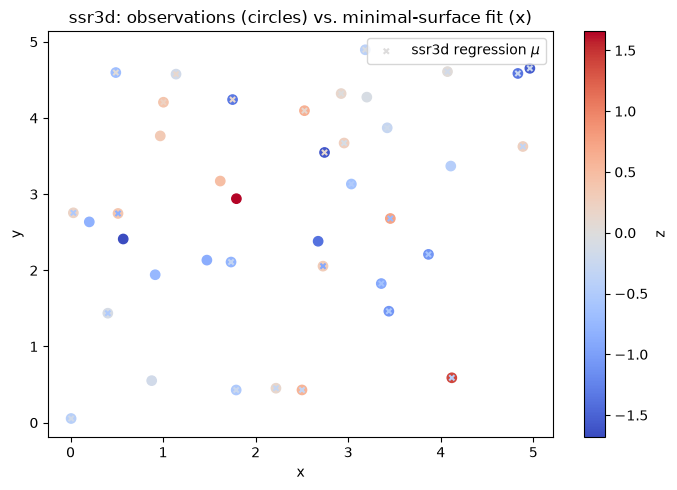

In [2]:
from bssunfold.core import ps_max_3d, ps_statistic_3d

df_k3 = pd.read_csv('../tests/data/sisireg3d/model_k3.csv')
coords = df_k3[['x', 'y']].to_numpy()
z = df_k3['z'].to_numpy()

model3d = ssr3d(coords, z, k=3, fn=2.5, iter=200)
print("matches the original R ssr3d output:",
      np.allclose(model3d.mu, df_k3['mu'].to_numpy(), atol=1e-10))

q_k3 = pd.read_csv('../tests/data/sisireg3d/predict_k3.csv')
pred_exp = ssr3d_predict(model3d, q_k3[['x', 'y']].to_numpy())
pred_ms = ssr3d_predict(model3d, q_k3[['x', 'y']].to_numpy(), ms=True)
print("matches the R predictions:",
      np.allclose(pred_exp, q_k3['p_exp'].to_numpy(), atol=1e-10),
      np.allclose(pred_ms, q_k3['p_ms'].to_numpy(), atol=1e-10))

fig, ax = plt.subplots(figsize=(7, 5))
s = ax.scatter(coords[:, 0], coords[:, 1], c=z, cmap="coolwarm", s=45)
ax.scatter(coords[:, 0], coords[:, 1], c=model3d.mu, cmap="coolwarm",
           s=14, marker="x", label="ssr3d regression $\\mu$")
ax.set(xlabel="x", ylabel="y",
       title="ssr3d: observations (circles) vs. minimal-surface fit (x)")
fig.colorbar(s, ax=ax, label="z")
ax.legend()
fig.tight_layout()
plt.show()


## 2. Synthetic scattered data and prediction

A noisy dome on scattered points; `ssr3d_predict` evaluates the
regression on new coordinates (``ms=True`` selects the reciprocal
minimal-surface weighted mean).

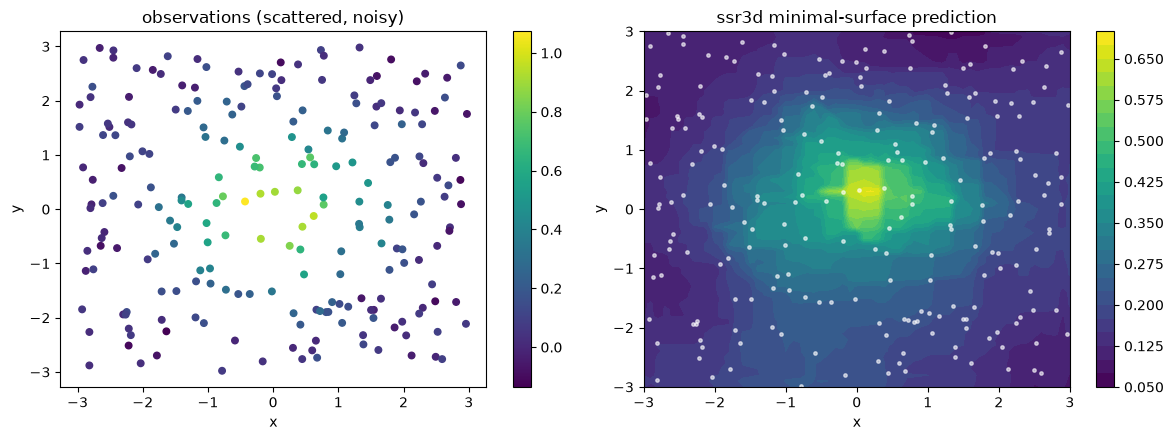

In [3]:
rng = np.random.default_rng(7)
xy_syn = rng.uniform(-3, 3, size=(220, 2))
z_syn = (np.exp(-(xy_syn[:, 0] ** 2 + xy_syn[:, 1] ** 2) / 2.5)
         + rng.normal(0, 0.08, len(xy_syn)))

model_syn = ssr3d(xy_syn, z_syn, iter=200)

gx, gy = np.meshgrid(np.linspace(-3, 3, 61), np.linspace(-3, 3, 61))
grid = np.column_stack([gx.ravel(), gy.ravel()])
z_pred = ssr3d_predict(model_syn, grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc = axes[0].scatter(xy_syn[:, 0], xy_syn[:, 1], c=z_syn, cmap="viridis",
                     s=22)
axes[0].set(title="observations (scattered, noisy)", xlabel="x", ylabel="y")
fig.colorbar(sc, ax=axes[0])

cs = axes[1].contourf(gx, gy, z_pred.reshape(gx.shape), levels=24,
                      cmap="viridis")
axes[1].scatter(xy_syn[:, 0], xy_syn[:, 1], c="white", s=6, alpha=0.6)
axes[1].set(title="ssr3d minimal-surface prediction", xlabel="x", ylabel="y")
fig.colorbar(cs, ax=axes[1])
fig.tight_layout()
plt.show()


## 3. Two-hidden-layer perceptron with the partial sum criterion

`ssrmlp_train` is the port of R `ssrMLP.R`: a sigmoid perceptron
whose training criterion is Metzner's **partial sum adequacy**
(`opt="ps"`) instead of plain least squares (`opt="lse"`).  The
partial sum statistics (`ps_max_3d`-family counterparts,
``check_ps``) bound the residual sign structure in every
neighbourhood — the same criterion used by the `unfold_ssr`
unfolding method.

ps  : L2 error = 1.111
lse : L2 error = 1.275


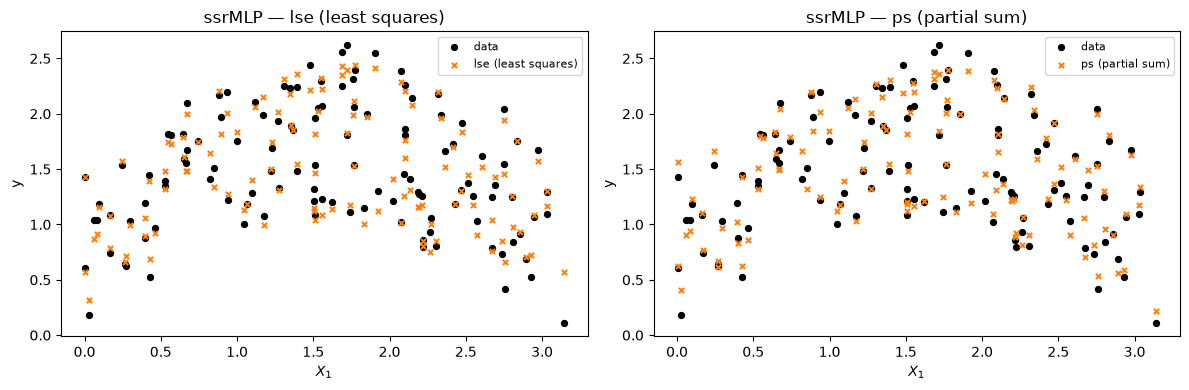

In [4]:
from bssunfold.core import ssrmlp_train, ssrmlp_predict, fii_prediction

# synthetic 1-D->2-D regression task: y = sin wave + noise
rng = np.random.default_rng(3)
X_syn = rng.uniform(0, np.pi, size=(120, 2))
Y_syn = np.sin(X_syn[:, 0]) + 0.5 * X_syn[:, 1] + rng.normal(0, 0.1, 120)

w_ps = ssrmlp_train(X_syn, Y_syn, opt="ps", max_iter=400, rng=0)
w_lse = ssrmlp_train(X_syn, Y_syn, opt="lse", max_iter=400, rng=0)

yp_ps = ssrmlp_predict(X_syn, w_ps)
yp_lse = ssrmlp_predict(X_syn, w_lse)
print(f"ps  : L2 error = {np.linalg.norm(yp_ps - Y_syn):.3f}")
print(f"lse : L2 error = {np.linalg.norm(yp_lse - Y_syn):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, name in zip(
    axes, (yp_lse, yp_ps), ("lse (least squares)", "ps (partial sum)")
):
    ax.scatter(X_syn[:, 0], Y_syn, s=18, c="k", label="data")
    ax.scatter(X_syn[:, 0], yp, s=14, c="C1", marker="x", label=name)
    ax.set(xlabel="$X_1$", ylabel="y", title=f"ssrMLP — {name}")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Summary

* `ssr3d` reproduces the original R output
  (R `ssr3d` + `ssr3d.c`, k = 3, fn = 2.5, 200 sweeps)
  to machine precision on the bundled fixture.
* The minimal-surface prediction reconstructs smooth
  structure from scattered noisy data.
* `ssrmlp_train(opt="ps")` constrains the residual
  sign structure through the partial sum criterion —
  the same adequacy machinery as `unfold_ssr`.